In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

In [4]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Шум Гаусса

In [5]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

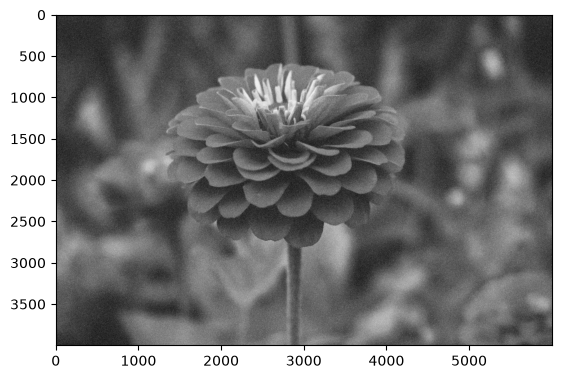

In [6]:
plt.imshow(image_noise_gauss, cmap="gray")

In [7]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

4498.495616958333 0.025890101157439005


# Равномерный шум

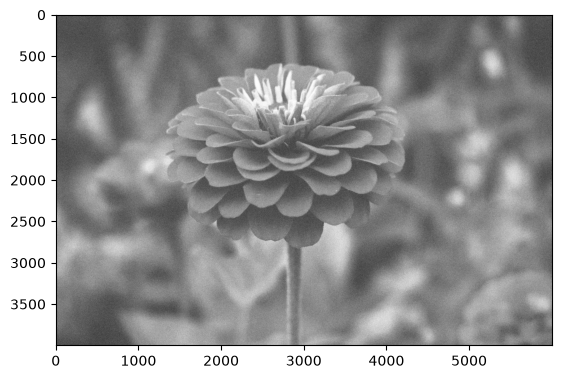

In [12]:
a = 0
b = 150
noise_uniform = np.random.uniform(a, b, image_gray.shape)
image_sp = image_gray.astype(np.float32) + noise_uniform
image_sp = np.clip(image_sp, 0, 255).astype(np.uint8)
plt.imshow(image_sp, cmap="gray")

In [13]:
plt.show()

In [14]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

7373.804953125 0.03168910942554923


# Медианный фильтр

In [15]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

844.0684315833333 0.1536194148874991


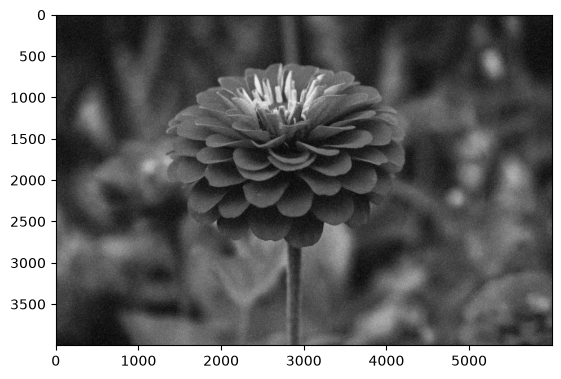

In [16]:
plt.imshow(image_gauss_median, cmap="gray")

In [17]:
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median_5)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median_5, full=True)
print(mse_gauss_median, ssim_gauss_median)

333.2517864166667 0.36576247704714865


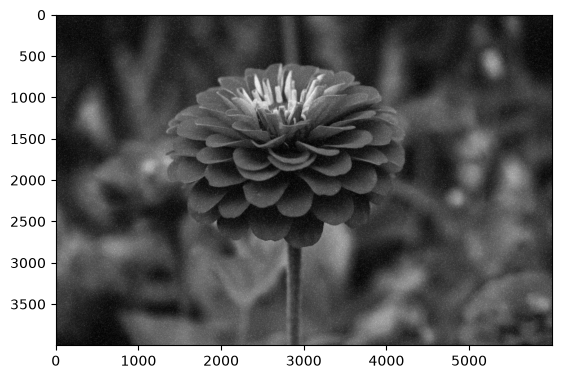

In [18]:
plt.imshow(image_gauss_median_5, cmap="gray")

In [19]:
image_sp_median = cv2.medianBlur(image_sp, 3)
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

6049.141308708334 0.093991787611974


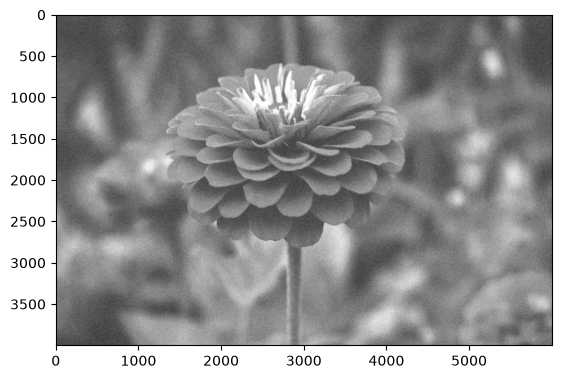

In [20]:
plt.imshow(image_sp_median, cmap="gray")

In [21]:
image_sp_median_5 = cv2.medianBlur(image_sp, 5)
mse_sp_median = mean_squared_error(image_gray, image_sp_median_5)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median_5, full=True)
print(mse_sp_median, ssim_sp_median)

5756.1084625 0.19680559401699813


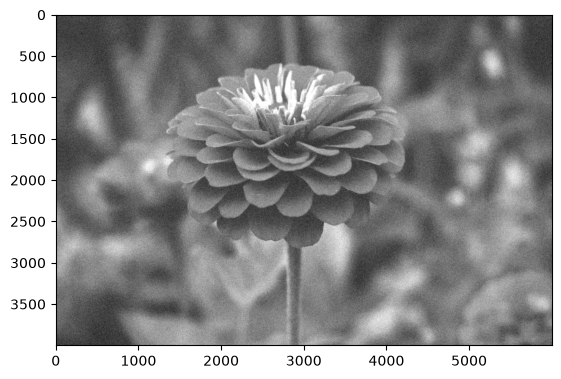

In [22]:
plt.imshow(image_sp_median_5, cmap="gray")

# Фильтр Гаусса

In [23]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1926.513640625 0.14123068983097767


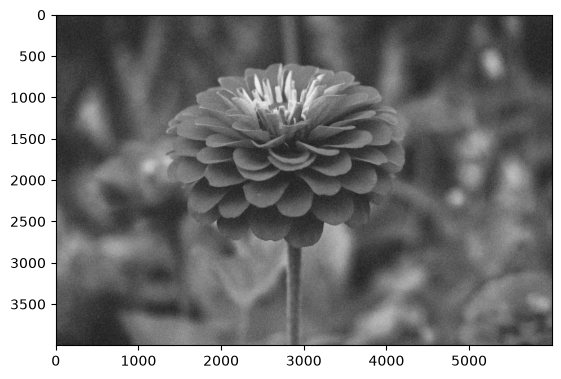

In [24]:
plt.imshow(image_gauss_gauss, cmap="gray")

In [25]:
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1729.2054128333334 0.2304045520784348


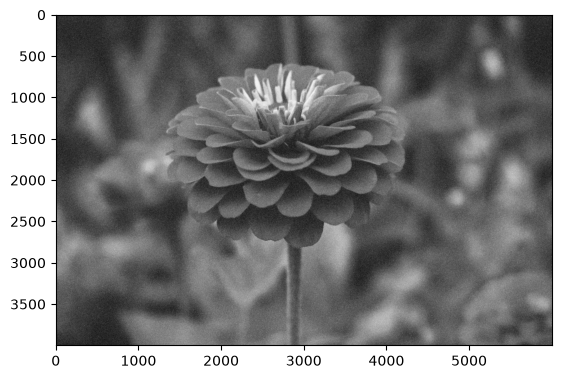

In [26]:
plt.imshow(image_gauss_gauss_5, cmap="gray")

In [27]:
image_sp_gauss = cv2.GaussianBlur(image_sp, (3,3), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

5788.363465958333 0.1602471930074124


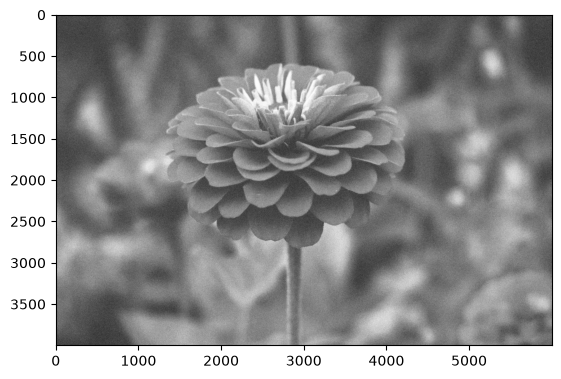

In [28]:
plt.imshow(image_sp_gauss, cmap="gray")

In [29]:
image_sp_gauss_5 = cv2.GaussianBlur(image_sp, (5,5), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss_5)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss_5, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

5664.474694375 0.2452428068535635


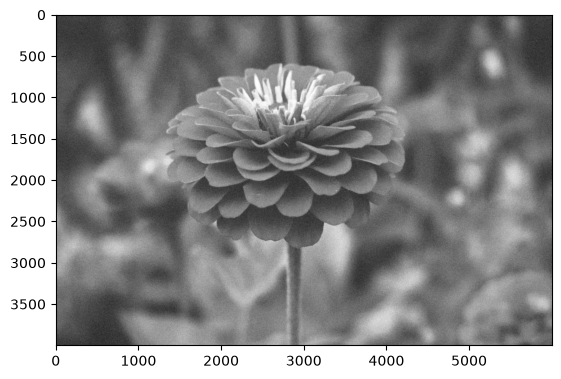

In [30]:
plt.imshow(image_sp_gauss_5, cmap="gray")

# Билатеральный фильтр

In [31]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1786.3903612083334 0.1045069515651392


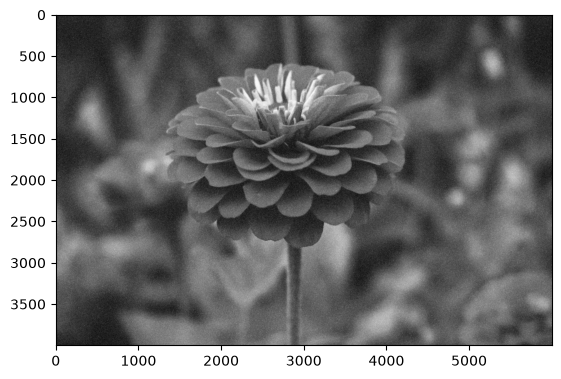

In [32]:
plt.imshow(image_gauss_bilat, cmap="gray")

In [33]:
image_gauss_bilat_150 = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat_150)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat_150, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1362.982392375 0.3525109210916518


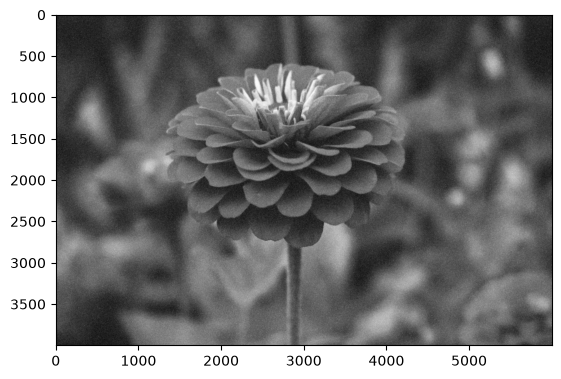

In [34]:
plt.imshow(image_gauss_bilat_150, cmap="gray")

In [35]:
image_sp_bilat = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

5722.058162541667 0.18944874852994265


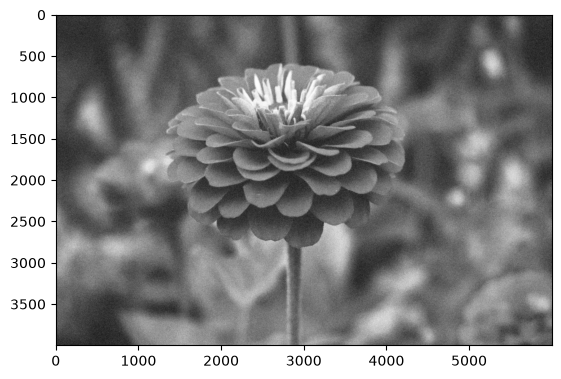

In [36]:
plt.imshow(image_sp_bilat, cmap="gray")

In [37]:
image_sp_bilat_150 = cv2.bilateralFilter(image_sp, 9, 150, 150)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat_150)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat_150, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

5582.045158416667 0.3851067037808383


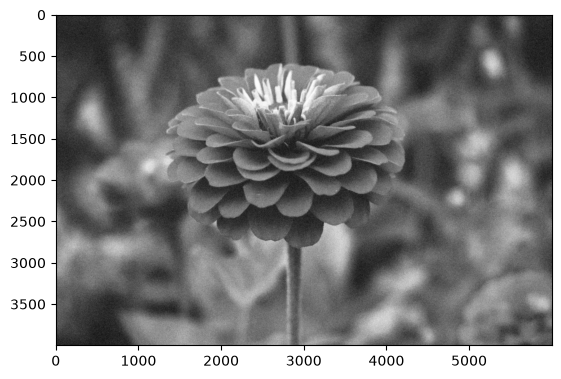

In [38]:
plt.imshow(image_sp_bilat_150, cmap="gray")

# Фильтр нелокальных средних

In [39]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 10)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4498.358609625 0.02608514366593419


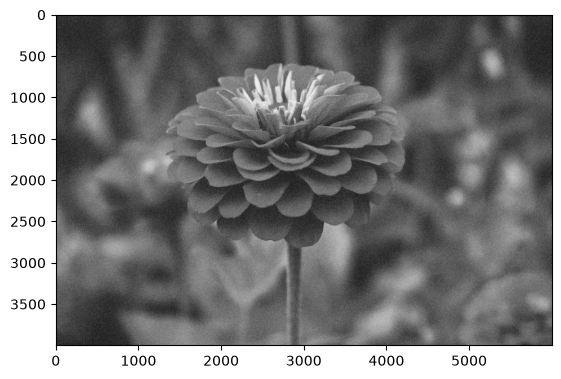

In [40]:
plt.imshow(image_gauss_nlm, cmap="gray")

In [41]:
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4486.269640875 0.028931002176420983


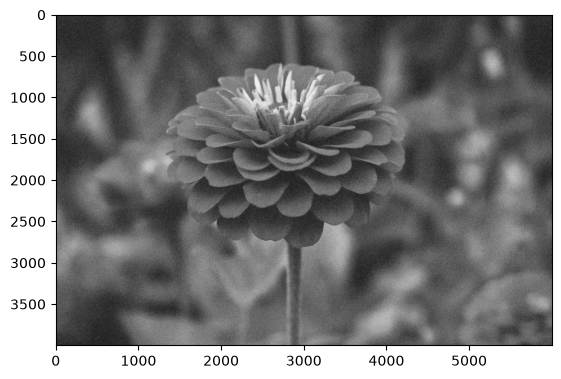

In [42]:
plt.imshow(image_gauss_nlm_20, cmap="gray")

In [43]:
image_sp_nlm = cv2.fastNlMeansDenoising(image_sp, h = 10)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

7373.504092041667 0.03274635029608958


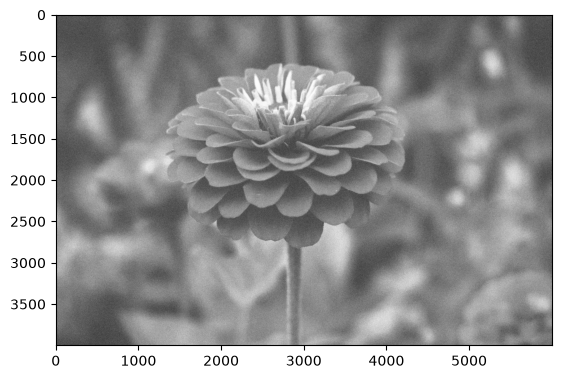

In [44]:
plt.imshow(image_sp_nlm, cmap="gray")

In [45]:
image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_sp, h = 20)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm_20)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm_20, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

7269.7880384166665 0.03750307664945034


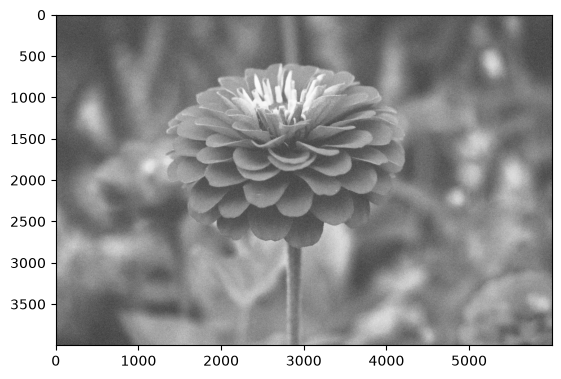

In [46]:
plt.imshow(image_sp_nlm_20, cmap="gray")

# Сравнение фильтров

## Для шума Гаусса

| Фильтр | Параметр | MSE | SSIM |
|---|---:|---:|---:|
| Медианный | 3 | 844.07 | 0.1536 |
| Медианный | 5 | 333.25 | 0.3658 |
| Гаусса | 3 | 1926.51 | 0.1412 |
| Гаусса | 5 | 1729.21 | 0.2304 |
| Билатеральный | 9, 75, 75 | 1362.98 | 0.3525 |
| Билатеральный | 9, 150, 150 | 1786.39 | 0.1045 | 
| Нелокальных средних | 10 | 4498.36 | 0.0261 |
| Нелокальных средних | 20 | 4486.27 | 0.0289 |

**Лучший: Медианный фильтр, параметр 5** — MSE = 333.25, SSIM = 0.3658.

## Для постоянного шума

| Фильтр | Параметр | MSE | SSIM |
|---|---:|---:|---:|
| Медианный | 3 | 6049.14 | 0.0940 |
| Медианный | 5 | 5756.11 | 0.1968 |
| Гаусса | 3 | 5788.36 | 0.1602 |
| Гаусса | 5 | 5664.47 | 0.2452 |
| Билатеральный | 9, 75, 75 | 5722.06 | 0.1894 |
| Билатеральный | 9, 150, 150 | 5582.05 | 0.3851 |
| Нелокальных средних | 10 | 7373.50 | 0.0327 |
| Нелокальных средних | 20 | 7269.79 | 0.0375 |

**Лучший: Билатеральный фильтр, параметр 9, 150, 150** — MSE = 5582.05, SSIM = 0.3851.